<a href="https://colab.research.google.com/github/sandralungahi/Data-and-AI-mini-projects/blob/regression_models/regression_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Week 7 Assignment

* Name: Sandra Lung'ahi
* Cyber Shujaa ID: CS-Da02-25069
* Regression Models





In [ ]:
# upload Datasets
from google.colab import files
uploaded = files.upload()


Saving areas.csv to areas.csv
Saving homeprices.csv to homeprices.csv


In [ ]:
#Import libraries
import numpy as np
import pandas as pd
import warnings as wr
wr.filterwarnings('ignore')

In [ ]:
# Load the homeprices dataset
df = pd.read_csv('homeprices.csv')
df.head()

,area,price
0,2600,550000
1,3000,565000
2,3200,610000
3,3600,680000
4,4000,725000


In [ ]:
# Explore dataset
print( '\n Dataset info \n ',df.info())
print('\n Dataset description \n',df.describe())
print( '\n Dataset shape \n',df.shape)
print('\n Dataset columns \n',df.columns)
print( '\n Null values \n', df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   area    5 non-null      int64
 1   price   5 non-null      int64
dtypes: int64(2)
memory usage: 212.0 bytes

 Dataset info 
  None

 Dataset description 
               area          price
count     5.000000       5.000000
mean   3280.000000  626000.000000
std     540.370243   74949.983322
min    2600.000000  550000.000000
25%    3000.000000  565000.000000
50%    3200.000000  610000.000000
75%    3600.000000  680000.000000
max    4000.000000  725000.000000

 Dataset shape 
 (5, 2)

 Dataset columns 
 Index(['area', 'price'], dtype='object')

 Null values 
 area     0
price    0
dtype: int64


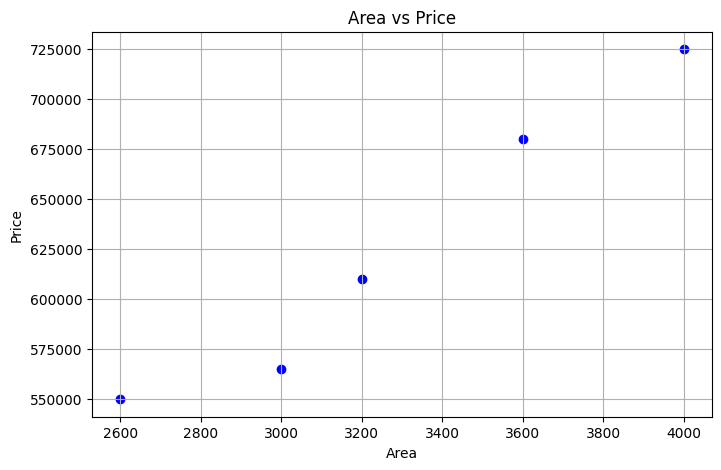

In [ ]:
# Visualize data
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(df['area'], df['price'], color= 'blue')
plt.xlabel('Area')
plt.ylabel('Price')
plt.title('Area vs Price')
plt.grid(True)
plt.show()

Since there are no missing values i'll split the dataset into the train and test set.

In [ ]:
# Define features
X = df[['area']]  # independent variable
y = df['price']   # dependent variable

# Split into training and test data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42)

In [ ]:
# Import libraries
from sklearn.linear_model import LinearRegression
from sklearn import metrics
# Build and fit model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully")
print(f"Intercept: {model.intercept_}")
print(f"Coefficient: {model.coef_[0]}")


Model trained successfully
Intercept: 213421.05263157893
Coefficient: 127.63157894736842


In [ ]:
# Predictions
y_pred = model.predict(X_test)

# Evaluation metrics
mae = metrics.mean_absolute_error(y_test, y_pred)
mse = metrics.mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = metrics.r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")


MAE: 16184.21
MSE: 490893351.80
RMSE: 22156.11
R² Score: 0.92


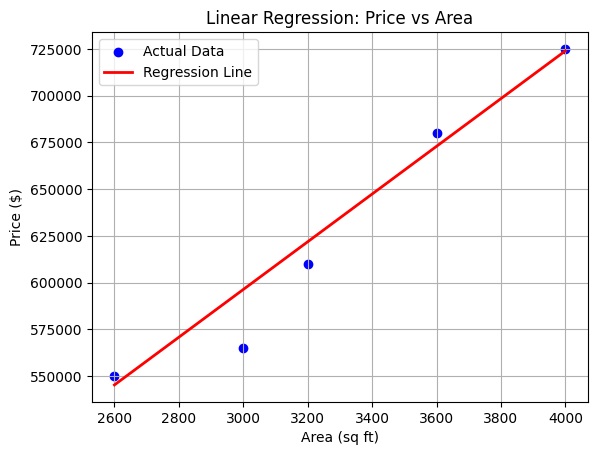

In [ ]:
# Visualisation of the regression line against actual data
plt.scatter(X, y, color='blue', label='Actual Data', marker= 'o')
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Regression Line')
plt.title('Linear Regression: Price vs Area')
plt.xlabel('Area (sq ft)')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# Load the new dataset
areas = pd.read_csv("areas.csv")
print(areas.head())

   area
0  1000
1  1500
2  2300
3  3540
4  4120


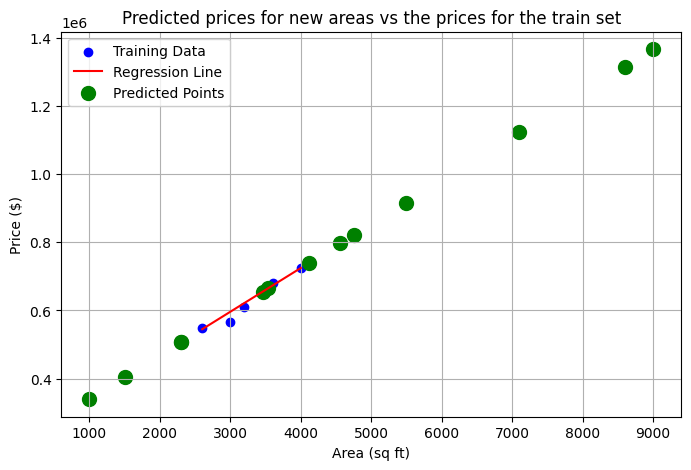

In [ ]:
# Predict prices for new areas
predicted_prices = model.predict(areas)

# Create a dataframe for visualization
pred_df = pd.DataFrame({'area': areas['area'], 'predicted_price': predicted_prices})

# Plot original training data
plt.figure(figsize=(8, 5))
plt.scatter(df['area'], df['price'], color='blue', marker= 'o', label='Training Data')

# Plot regression line for the entire range
plt.plot(df['area'], model.predict(df[['area']]), color='red', label='Regression Line')

# Plot predicted points for new areas
plt.scatter(pred_df['area'], pred_df['predicted_price'], color='green', marker='o', s=100, label='Predicted Points')

# Add labels and legend
plt.title("Predicted prices for new areas vs the prices for the train set")
plt.xlabel("Area (sq ft)")
plt.ylabel("Price ($)")
plt.legend()
plt.grid(True)
plt.show()